In [1]:
import os
import sys

In [2]:
sys.path.append(os.path.join(os.getcwd(), "../"))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from datetime import datetime

In [5]:
from src.python.utils import load_file_chunks

In [6]:
DATA_PATH = os.path.join(os.getcwd(), "../", "data")
OPTIONS_DATA_PATH = os.path.join(DATA_PATH, "spx_options_processed.csv")

In [7]:
start_date = datetime(2015, 1, 1)
end_date = datetime(2015, 2, 1)

In [8]:
df = load_file_chunks(OPTIONS_DATA_PATH, start_date, end_date)

In [9]:
df.head()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
1932708,2015-01-02,2015-01-17,C,1000.0,1056.7,1059.9,1500,41884,1.598820,0.993924,...,6.129469,-106.8664,101234072,2058.2,-0.00034,15,1058.30,3.2,0.485861,-0.721832
1932709,2015-01-02,2015-01-17,C,1025.0,1031.7,1034.9,0,0,1.548029,0.993750,...,6.300900,-106.2628,101234073,2058.2,-0.00034,15,1033.30,3.2,0.498008,-0.697139
1932710,2015-01-02,2015-01-17,C,1050.0,1006.7,1009.8,0,52,1.490604,0.993763,...,6.288437,-100.9584,101234074,2058.2,-0.00034,15,1008.25,3.1,0.510155,-0.673042
1932711,2015-01-02,2015-01-17,C,1075.0,981.7,984.8,0,4,1.442365,0.993582,...,6.466263,-100.3422,101234075,2058.2,-0.00034,15,983.25,3.1,0.522301,-0.649511
1932712,2015-01-02,2015-01-17,C,1100.0,956.7,959.9,0,425,1.402610,0.993187,...,6.850747,-104.3517,101234076,2058.2,-0.00034,15,958.30,3.2,0.534448,-0.626522


In [10]:
df.tail()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
2013666,2015-01-30,2015-06-30,P,2450.0,464.40,475.60,0,0,0.175458,-0.958429,...,96.92561,-48.563960,106123051,1994.99,-0.012992,151,470.000,11.20,1.228076,0.205449
2013667,2015-01-30,2015-06-30,P,2500.0,514.20,525.40,0,0,0.187366,-0.961659,...,89.28925,-48.189610,104605642,1994.99,-0.012992,151,519.800,11.20,1.253139,0.225652
2013668,2015-01-30,2015-06-30,P,850.0,0.10,0.95,0,0,0.498217,-0.002514,...,10.00224,-6.098301,106720275,1994.99,-0.012992,151,0.525,0.85,0.426067,-0.853158
2013669,2015-01-30,2015-06-30,P,900.0,0.30,1.15,0,38,0.483238,-0.003483,...,13.41596,-7.940055,104605644,1994.99,-0.012992,151,0.725,0.85,0.451130,-0.796000
2013670,2015-01-30,2015-06-30,P,950.0,0.55,1.40,0,0,0.468055,-0.004709,...,17.57365,-10.082660,106720276,1994.99,-0.012992,151,0.975,0.85,0.476193,-0.741932


In [11]:
df.describe()

,date,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
count,80963,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,8.096300e+04,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000
mean,2015-01-16 13:03:34.542445,1819.034497,125.905825,128.913055,163.051097,1647.469301,0.261202,0.143369,0.001274,138.741969,-93.301122,1.058689e+08,2028.166784,-0.001593,60.530922,127.409440,3.007230,0.896961,-0.123558
min,2015-01-02 00:00:00,200.000000,0.050000,0.100000,0.000000,0.000000,0.050190,-0.999513,0.000000,0.000826,-622.212000,1.012341e+08,1992.670000,-0.018278,8.000000,0.075000,0.050000,0.100251,-2.300077
25%,2015-01-08 00:00:00,1635.000000,4.200000,4.900000,0.000000,0.000000,0.164073,-0.150473,0.000257,38.731725,-134.132950,1.058888e+08,2011.270000,-0.009248,35.000000,4.550000,0.800000,0.806530,-0.215014
50%,2015-01-15 00:00:00,1850.000000,39.100000,40.900000,0.000000,4.000000,0.236000,-0.005404,0.000826,105.119300,-81.458710,1.061822e+08,2025.900000,-0.005492,57.000000,40.000000,1.700000,0.910990,-0.093223
75%,2015-01-23 00:00:00,2045.000000,187.500000,192.100000,3.000000,150.000000,0.314879,0.783207,0.002010,220.058200,-37.074465,1.063956e+08,2044.810000,0.004732,77.000000,189.800000,3.400000,1.008167,0.008134
max,2015-01-30 00:00:00,3500.000000,1556.500000,1559.500000,61151.000000,150345.000000,2.976005,0.999516,0.011269,570.204800,33.986350,1.067203e+08,2063.150000,0.017888,179.000000,1558.000000,12.000000,1.754395,0.562124
std,NaN,295.348772,178.336568,180.767848,1119.224643,7032.612649,0.142921,0.591322,0.001288,117.975180,75.677860,1.046844e+06,21.525934,0.010478,36.317467,179.548517,3.348613,0.145816,0.178134


#### Open Interest Heatmap:
A 2D map showing where contracts are concentrated. For:
- Identifying max pain / pinning levels
- Dealer exposure zones
- Magnet strikes near expiry

In [12]:
oi_matrix = df.pivot_table(
    index='strike_price',
    columns='exdate',
    values='open_interest',
    aggfunc='sum'
).fillna(0)

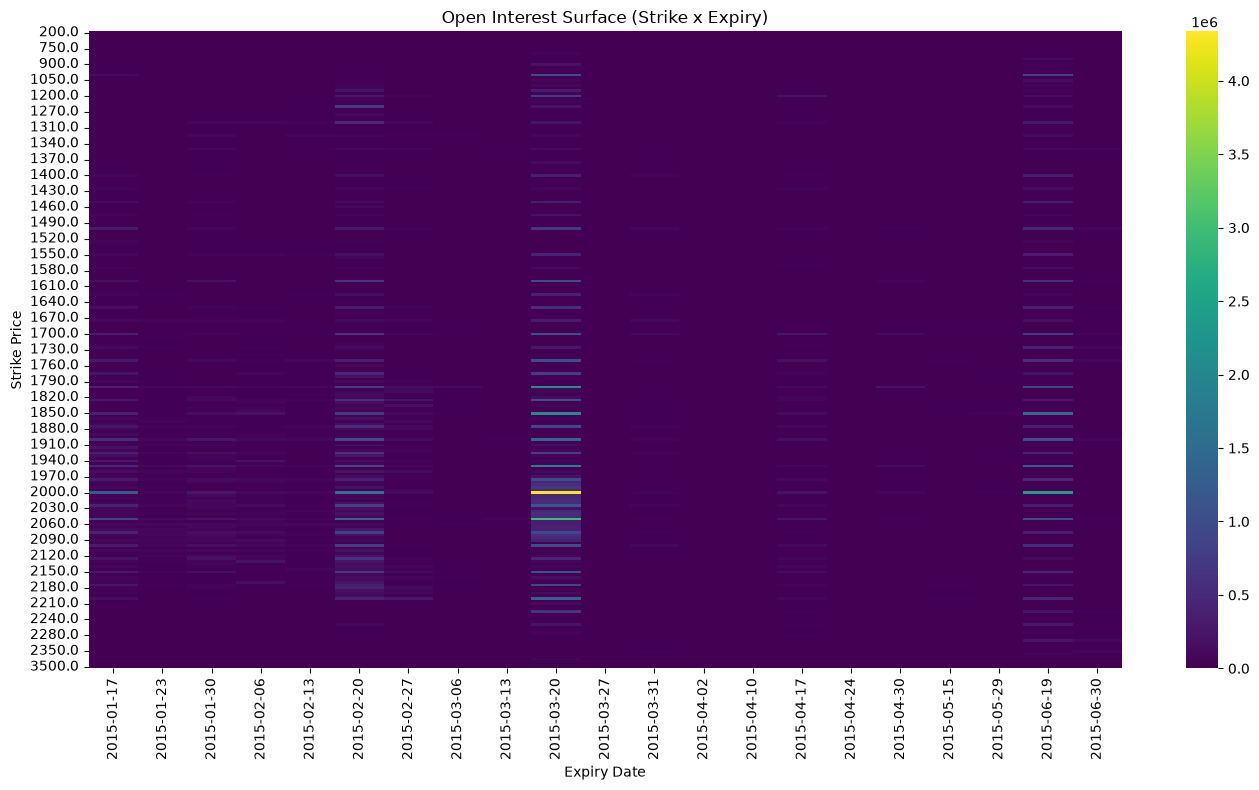

In [13]:
plt.figure(figsize=(14,8))

sns.heatmap(
    oi_matrix,
    cmap='viridis',
    linewidths=0.0
)

plt.title("Open Interest Surface (Strike x Expiry)")
plt.xlabel("Expiry Date")
plt.ylabel("Strike Price")
plt.tight_layout()
plt.show()